In [ ]:
from utils import load_nws_and_jsons

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path
from concurrent.futures import ProcessPoolExecutor

from scipy.stats import mode
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import pypsa
import logging
logging.getLogger('pypsa').setLevel(logging.ERROR)

In [2]:
qmc_type = 'lhs'
data_path = f"data/sensitivity_test/mixed_w_cboundaries_{qmc_type}/"
fig_path = "figures/09_mixed_sensitivity_test/"
baseline = pypsa.Network(data_path+'baseline_1.nc')

In [3]:
baseline_p_nom = pd.concat((baseline.generators.p_nom_opt, baseline.storage_units.p_nom_opt)).abs().values
mean_baseline_p_nom = baseline_p_nom.mean()
std_baseline_p_nom = baseline_p_nom.std()
baseline_p_nom_standardized = (baseline_p_nom - mean_baseline_p_nom) / std_baseline_p_nom

In [4]:
with ProcessPoolExecutor() as executor:
    results = executor.map(load_nws_and_jsons, [f for f in Path(data_path).iterdir() if f.is_dir()])
data, p_nom_opt_vals = {}, []
for res in filter(None, results):
    folder_name, metadata_dict, pNomOptArr = res # type: ignore ## Ignore VSCode warning
    data[folder_name] = metadata_dict
    p_nom_opt_vals.append(abs(pNomOptArr))
p_nom_opt_vals_standardized = [(p - mean_baseline_p_nom) / std_baseline_p_nom  for p in p_nom_opt_vals]

len(p_nom_opt_vals)

Missing data for folder multi-cost-capital_environment_operation_reliability_risk


500

In [5]:
tiled_baseline_p_nom_standardized = np.tile(baseline_p_nom_standardized, (len(p_nom_opt_vals),1))

# Pairwise Cosine Similarity
cos_matrix = cosine_similarity(tiled_baseline_p_nom_standardized, np.array(p_nom_opt_vals_standardized))
# Pairwise Euclidean Distance
euc_matrix = euclidean_distances(tiled_baseline_p_nom_standardized, np.array(p_nom_opt_vals_standardized))

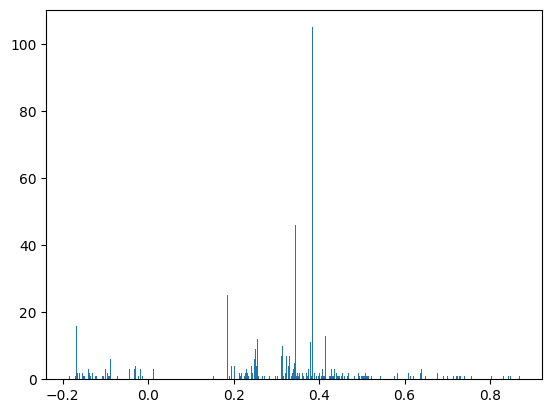

In [6]:
plt.hist(np.diag(cos_matrix), bins=len(p_nom_opt_vals))
plt.show()

In [7]:
peak_indicies = np.where(np.diag(cos_matrix)==mode(np.diag(cos_matrix)).mode)[0]
peak_indicies

array([  3,  14,  18,  23,  25,  28,  34,  36,  39,  40,  54,  70,  72,
        74,  78,  85,  93, 109, 114, 115, 120, 123, 127, 132, 139, 140,
       141, 143, 144, 147, 154, 155, 157, 164, 173, 174, 177, 179, 188,
       189, 201, 202, 214, 218, 219, 226, 233, 241, 244, 247, 248, 254,
       257, 259, 265, 276, 284, 294, 297, 305, 306, 307, 317, 324, 334,
       341, 345, 356, 357, 361, 365, 369, 374, 378, 385, 397, 423, 424,
       427, 436, 447, 458, 461, 462, 467, 471, 474, 477, 478, 487, 489,
       491, 494, 495])

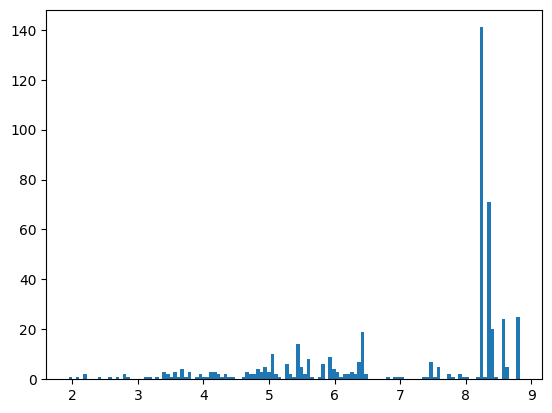

In [8]:
plt.hist(np.diag(euc_matrix), bins=len(p_nom_opt_vals)//4)
#plt.yscale('log')
plt.show()

In [9]:
peak_indicies_euc_mtx = np.where(np.diag(euc_matrix)==mode(np.diag(euc_matrix)).mode)[0]

---


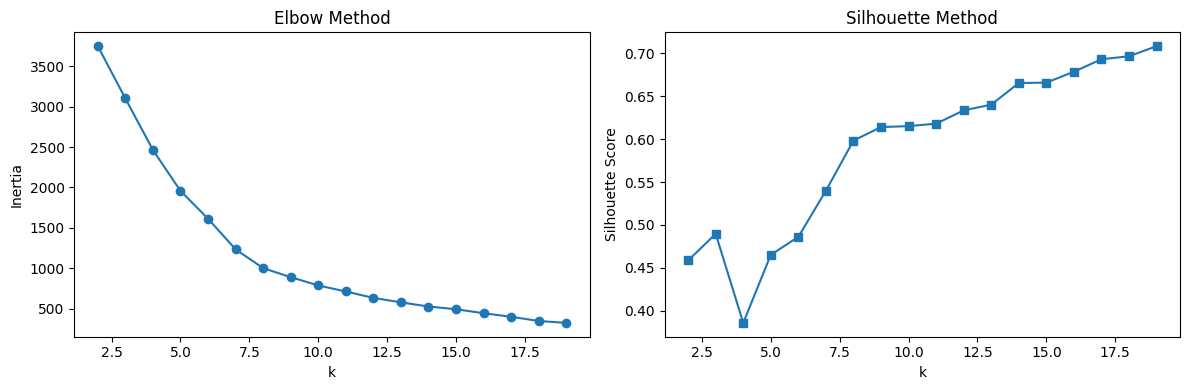

Optimal k = 19  (silhouette: 0.708)


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(np.array(p_nom_opt_vals))

inertias, sil_scores = [], []
K_range = range(2, min(20, len(X_scaled)))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'o-')
ax1.set(xlabel='k', ylabel='Inertia', title='Elbow Method')
ax2.plot(K_range, sil_scores, 's-')
ax2.set(xlabel='k', ylabel='Silhouette Score', title='Silhouette Method')
plt.tight_layout()
#plt.savefig(fig_path + 'clustering_elbow_silhouette.png')
plt.show()

optimal_k = K_range[sil_scores.index(max(sil_scores))]
print(f"Optimal k = {optimal_k}  (silhouette: {max(sil_scores):.3f})")

In [11]:
n_clusters = min(14, optimal_k)
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Project baseline into PCA space
baseline_p_nom = pd.concat((baseline.generators.p_nom_opt, baseline.storage_units.p_nom_opt))
baseline_scaled = scaler.transform(baseline_p_nom.values.reshape(1, -1))
baseline_pca = pca.transform(baseline_scaled)

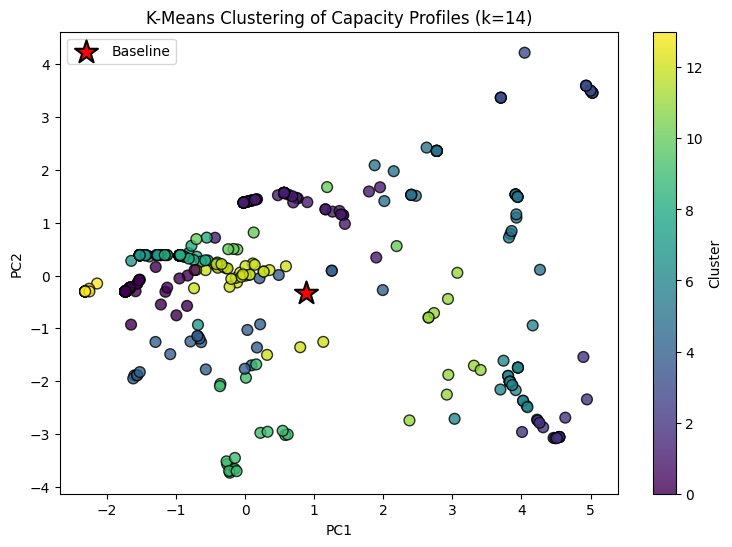

In [12]:
pca_comps = [0,1]

plt.figure(figsize=(9,6))
scatter = plt.scatter(X_pca[:, pca_comps[0]], X_pca[:, pca_comps[1]], c=labels,# cmap='tab10',
                      edgecolors='k', s=60, alpha=0.8)
plt.scatter(
    baseline_pca[:, pca_comps[0]], baseline_pca[:, pca_comps[1]],
    marker='*', s=300, c='red', edgecolors='k', linewidths=1.5,
    label='Baseline'
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC{pca_comps[0]+1}')
plt.ylabel(f'PC{pca_comps[1]+1}')
plt.title(f'K-Means Clustering of Capacity Profiles (k={n_clusters})')
plt.legend()
#plt.savefig(fig_path + 'clustering_pca.png')
plt.show()

# Store labels back in data dict
for i, (hash_id, v) in enumerate(data.items()):
    v['cluster'] = int(labels[i])

In [ ]:


# 1. Konvertálás DataFrame-mé és a szótár frissítése
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
df_pca["Cluster"] = labels
df_pca["Hash_ID"] = list(data.keys())

for i, (hash_id, v) in enumerate(data.items()):
    v["cluster"] = int(labels[i])

# 2. Színpaletta generálása a klaszterek számára
unique_clusters = sorted(df_pca["Cluster"].unique())

# Plotly színgenerátor (pl. Qualitatív színskála, mint a Vivid vagy D3)
# Igény szerint cserélhető: px.colors.qualitative.Plotly, Set1, Bold, stb.
colors = px.colors.qualitative.Vivid

fig = go.Figure()

# 3. Klaszterek hozzáadása KÜLÖN-KÜLÖN trace-ként (így kapcsolhatók ki/be a legend-ben)
for cluster_id in unique_clusters:
    cluster_df = df_pca[df_pca["Cluster"] == cluster_id]
    color = colors[cluster_id % len(colors)]  # Szín kiosztása ciklikusan

    fig.add_trace(
        go.Scatter3d(
            x=cluster_df["PC1"],
            y=cluster_df["PC2"],
            z=cluster_df["PC3"],
            mode="markers",
            marker=dict(
                size=6,
                color=color,
                line=dict(width=1, color="black"),  # Sötét körvonal
                opacity=0.8,
            ),
            text=cluster_df["Hash_ID"],
            hovertemplate="<b>Hash ID:</b> %{text}<br>"
            + "<b>PC1:</b> %{x:.2f}<br>"
            + "<b>PC2:</b> %{y:.2f}<br>"
            + "<b>PC3:</b> %{z:.2f}<br>"
            + f"<b>Cluster:</b> {cluster_id}<extra></extra>",
            name=f"Cluster {cluster_id}",  # Ez jelenik meg a Legend-ben
        )
    )

# 4. A Baseline elem hozzáadása
fig.add_trace(
    go.Scatter3d(
        x=[baseline_pca[0, 0]],
        y=[baseline_pca[0, 1]],
        z=[baseline_pca[0, 2]],
        mode="markers",
        marker=dict(
            size=12,
            symbol="cross",
            color="red",
            line=dict(width=1.5, color="black"),
        ),
        name="Baseline",
        hovertemplate="<b>Baseline Profile</b><br>"
        + "<b>PC1:</b> %{x:.2f}<br>"
        + "<b>PC2:</b> %{y:.2f}<br>"
        + "<b>PC3:</b> %{z:.2f}<extra></extra>",
    )
)

# 5. Layout beállítások (jelmagyarázat testreszabása)
fig.update_layout(
    title=f"K-Means Clustering (k={n_clusters})",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
        camera=dict(eye=dict(x=1.5, y=1.2, z=0.6)),
    ),
    legend=dict(
        title="Clusters",
        itemsizing="constant",  # A jelmagyarázatban a pontok egységes méretűek maradnak
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40),
)

# 6. Megjelenítés és mentés HTML-be
fig.show()
fig.write_html(fig_path + f"clustering_pca_{qmc_type}.html")

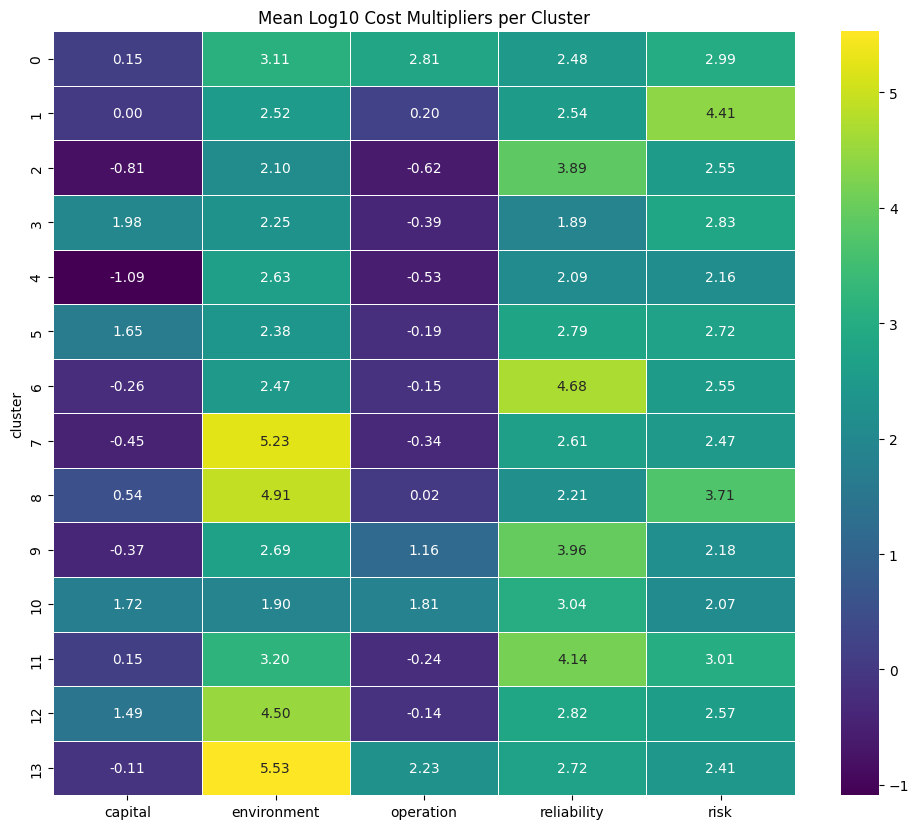


Cluster sizes:
0     132
1      72
2      16
3      13
4      23
5      30
6      28
7      66
8      39
9      18
10      7
11     10
12     30
13     16
Name: count, dtype: int64


In [14]:
# Map cost multipliers to clusters
cost_df = pd.DataFrame([
    {k:np.log10(x) for k, x in v['metadata']['canonical_cost_multipliers'].items()}
    for v in data.values()
])
cost_df['cluster'] = labels
cost_centers = cost_df.groupby('cluster').mean()

fig, ax = plt.subplots(figsize=(10, max(4, n_clusters * 0.6)))
sns.heatmap(cost_centers, cmap='viridis', annot=True, fmt='.2f',
            linewidths=0.5, ax=ax)
ax.set_title('Mean Log10 Cost Multipliers per Cluster')
plt.tight_layout()
#plt.savefig(fig_path + 'clustering_cost_profiles.png')
plt.show()

print(f"\nCluster sizes:")
print(pd.Series(labels).value_counts().sort_index())